In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
import pandas as pd
import numpy as np

# Reproducible random data
np.random.seed(42)

# Number of customers
n = 500

# Customer IDs
customer_ids = [f"C{str(i).zfill(4)}" for i in range(1, n + 1)]

# Customer data
customers = pd.DataFrame({
    "customer_id": customer_ids,
    "age": np.random.randint(18, 61, n),
    "gender": np.random.choice(
        ["Male", "Female"],
        n
    ),
    "city": np.random.choice(
        ["Karachi", "Lahore", "Islamabad", "Rawalpindi", "Faisalabad", "Multan"],
        n
    ),
    "signup_date": pd.to_datetime(
        np.random.choice(
            pd.date_range("2023-01-01", "2026-06-30"),
            n
        )
    )
})

# Display first 10 customers
customers.head(10)

,customer_id,age,gender,city,signup_date
0,C0001,56,Female,Multan,2023-03-10
1,C0002,46,Male,Lahore,2025-01-20
2,C0003,32,Male,Multan,2026-03-17
3,C0004,60,Female,Rawalpindi,2026-06-21
4,C0005,25,Female,Karachi,2025-08-15
5,C0006,38,Male,Karachi,2023-12-31
6,C0007,56,Female,Faisalabad,2024-04-26
7,C0008,36,Female,Rawalpindi,2023-07-20
8,C0009,40,Male,Karachi,2023-06-03
9,C0010,28,Female,Rawalpindi,2023-03-14


In [3]:
print("Number of customers:", len(customers))

Number of customers: 500


In [4]:
customers.to_csv("../data/customers.csv", index=False)

print("customers.csv created successfully!")

customers.csv created successfully!


In [5]:
# Number of products
n_products = 100

# Product IDs
product_ids = [f"P{str(i).zfill(4)}" for i in range(1, n_products + 1)]

# Product names
product_names = [
    "Wireless Mouse",
    "Mechanical Keyboard",
    "USB-C Cable",
    "Laptop Stand",
    "Bluetooth Speaker",
    "Power Bank",
    "Headphones",
    "Smart Watch",
    "Backpack",
    "Phone Case"
]

# Categories
categories = [
    "Electronics",
    "Accessories",
    "Fashion",
    "Home & Kitchen"
]

# Create product dataset
products = pd.DataFrame({
    "product_id": product_ids,
    "product_name": np.random.choice(product_names, n_products),
    "category": np.random.choice(categories, n_products),
    "price": np.random.randint(500, 50000, n_products)
})

# Show first 10 products
products.head(10)

,product_id,product_name,category,price
0,P0001,Smart Watch,Electronics,5260
1,P0002,Headphones,Home & Kitchen,33279
2,P0003,Backpack,Fashion,22136
3,P0004,Laptop Stand,Home & Kitchen,16853
4,P0005,Mechanical Keyboard,Electronics,12056
5,P0006,Headphones,Accessories,28098
6,P0007,Power Bank,Home & Kitchen,12063
7,P0008,Wireless Mouse,Electronics,47319
8,P0009,Backpack,Electronics,44290
9,P0010,Backpack,Fashion,8734


In [6]:
print("Number of products:", len(products))

Number of products: 100


In [7]:
products.to_csv("../data/products.csv", index=False)

print("products.csv created successfully!")

products.csv created successfully!


In [8]:
# Number of orders
n_orders = 3000

# Order IDs
order_ids = [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)]

# Random customers and products
order_customer_ids = np.random.choice(
    customers["customer_id"],
    n_orders
)

order_product_ids = np.random.choice(
    products["product_id"],
    n_orders
)

# Order dates
order_dates = pd.to_datetime(
    np.random.choice(
        pd.date_range("2025-01-01", "2026-06-30"),
        n_orders
    )
)

# Quantities
quantities = np.random.randint(1, 6, n_orders)

# Discount percentages
discounts = np.random.choice(
    [0, 5, 10, 15, 20, 25],
    n_orders
)

# Create orders dataset
orders = pd.DataFrame({
    "order_id": order_ids,
    "customer_id": order_customer_ids,
    "product_id": order_product_ids,
    "order_date": order_dates,
    "quantity": quantities,
    "discount_percent": discounts
})

# Sort by date
orders = orders.sort_values("order_date").reset_index(drop=True)

# Show first 10 orders
orders.head(10)

,order_id,customer_id,product_id,order_date,quantity,discount_percent
0,O01913,C0188,P0095,2025-01-01,4,0
1,O02968,C0385,P0048,2025-01-01,1,25
2,O00428,C0343,P0005,2025-01-01,5,25
3,O00753,C0459,P0096,2025-01-01,1,10
4,O00701,C0014,P0017,2025-01-02,1,25
5,O00020,C0011,P0040,2025-01-02,3,25
6,O00747,C0116,P0016,2025-01-02,1,25
7,O02354,C0003,P0055,2025-01-02,1,0
8,O02484,C0099,P0058,2025-01-02,2,25
9,O01036,C0399,P0092,2025-01-02,4,25


In [9]:
print("Number of orders:", len(orders))

Number of orders: 3000


In [10]:
orders.to_csv("../data/orders.csv", index=False)

print("orders.csv created successfully!")

orders.csv created successfully!


In [11]:
import sqlite3

# Create/connect to SQLite database
conn = sqlite3.connect("../database/shopsmart.db")

print("SQLite database connected successfully!")

SQLite database connected successfully!


In [12]:
customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

print("All 3 tables successfully added to SQLite!")

All 3 tables successfully added to SQLite!


In [13]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

tables

,name
0,customers
1,products
2,orders


In [14]:
result = pd.read_sql_query(
    """
    SELECT *
    FROM customers
    LIMIT 10;
    """,
    conn
)

result

,customer_id,age,gender,city,signup_date
0,C0001,56,Female,Multan,2023-03-10 00:00:00
1,C0002,46,Male,Lahore,2025-01-20 00:00:00
2,C0003,32,Male,Multan,2026-03-17 00:00:00
3,C0004,60,Female,Rawalpindi,2026-06-21 00:00:00
4,C0005,25,Female,Karachi,2025-08-15 00:00:00
5,C0006,38,Male,Karachi,2023-12-31 00:00:00
6,C0007,56,Female,Faisalabad,2024-04-26 00:00:00
7,C0008,36,Female,Rawalpindi,2023-07-20 00:00:00
8,C0009,40,Male,Karachi,2023-06-03 00:00:00
9,C0010,28,Female,Rawalpindi,2023-03-14 00:00:00


In [15]:
query = """
SELECT *
FROM orders
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,order_id,customer_id,product_id,order_date,quantity,discount_percent
0,O01913,C0188,P0095,2025-01-01 00:00:00,4,0
1,O02968,C0385,P0048,2025-01-01 00:00:00,1,25
2,O00428,C0343,P0005,2025-01-01 00:00:00,5,25
3,O00753,C0459,P0096,2025-01-01 00:00:00,1,10
4,O00701,C0014,P0017,2025-01-02 00:00:00,1,25
5,O00020,C0011,P0040,2025-01-02 00:00:00,3,25
6,O00747,C0116,P0016,2025-01-02 00:00:00,1,25
7,O02354,C0003,P0055,2025-01-02 00:00:00,1,0
8,O02484,C0099,P0058,2025-01-02 00:00:00,2,25
9,O01036,C0399,P0092,2025-01-02 00:00:00,4,25


In [16]:
query = """
SELECT COUNT(*) AS total_orders
FROM orders;
"""

result = pd.read_sql_query(query, conn)

result

,total_orders
0,3000


In [17]:
query = """
SELECT SUM(quantity) AS total_items_sold
FROM orders;
"""

result = pd.read_sql_query(query, conn)

result

,total_items_sold
0,9184


In [18]:
query = """
SELECT
    customer_id,
    COUNT(*) AS total_orders
FROM orders
GROUP BY customer_id
ORDER BY total_orders DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,customer_id,total_orders
0,C0154,14
1,C0405,13
2,C0260,13
3,C0188,13
4,C0149,13
5,C0483,12
6,C0425,12
7,C0313,12
8,C0109,12
9,C0049,12


In [19]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    o.product_id,
    p.product_name,
    p.category,
    p.price,
    o.quantity,
    o.discount_percent
FROM orders AS o
JOIN products AS p
    ON o.product_id = p.product_id
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,order_id,customer_id,product_id,product_name,category,price,quantity,discount_percent
0,O01913,C0188,P0095,Mechanical Keyboard,Accessories,23884,4,0
1,O02968,C0385,P0048,Laptop Stand,Accessories,35405,1,25
2,O00428,C0343,P0005,Mechanical Keyboard,Electronics,12056,5,25
3,O00753,C0459,P0096,Mechanical Keyboard,Accessories,645,1,10
4,O00701,C0014,P0017,Smart Watch,Electronics,25096,1,25
5,O00020,C0011,P0040,Smart Watch,Electronics,13967,3,25
6,O00747,C0116,P0016,Smart Watch,Electronics,39838,1,25
7,O02354,C0003,P0055,Bluetooth Speaker,Electronics,7552,1,0
8,O02484,C0099,P0058,Wireless Mouse,Accessories,19243,2,25
9,O01036,C0399,P0092,Headphones,Accessories,7727,4,25


In [20]:
query = """
SELECT
    SUM(
        quantity * price * (1 - discount_percent / 100.0)
    ) AS total_revenue
FROM orders AS o
JOIN products AS p
    ON o.product_id = p.product_id;
"""

result = pd.read_sql_query(query, conn)

result

,total_revenue
0,219366570.6


In [21]:
query = """
SELECT
    p.category,
    SUM(
        o.quantity * p.price *
        (1 - o.discount_percent / 100.0)
    ) AS revenue
FROM orders AS o
JOIN products AS p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;
"""

result = pd.read_sql_query(query, conn)

result

,category,revenue
0,Electronics,69039851.50
1,Accessories,58530479.45
2,Fashion,46876925.85
3,Home & Kitchen,44919313.80


In [22]:
query = """
SELECT
    p.product_name,
    p.category,
    SUM(
        o.quantity * p.price *
        (1 - o.discount_percent / 100.0)
    ) AS revenue
FROM orders AS o
JOIN products AS p
    ON o.product_id = p.product_id
GROUP BY p.product_id, p.product_name, p.category
ORDER BY revenue DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,product_name,category,revenue
0,USB-C Cable,Fashion,5600272.80
1,Smart Watch,Electronics,4643104.00
2,Laptop Stand,Home & Kitchen,4616087.00
3,Wireless Mouse,Electronics,4569916.90
4,Bluetooth Speaker,Accessories,4545203.15
5,Mechanical Keyboard,Fashion,4415719.60
6,Wireless Mouse,Home & Kitchen,4328145.60
7,Power Bank,Electronics,4144763.55
8,Smart Watch,Home & Kitchen,4076678.25
9,Phone Case,Home & Kitchen,4040715.00


In [23]:
# Load data from SQLite into Pandas

customers_df = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)

products_df = pd.read_sql_query(
    "SELECT * FROM products",
    conn
)

orders_df = pd.read_sql_query(
    "SELECT * FROM orders",
    conn
)

print("Customers:", customers_df.shape)
print("Products:", products_df.shape)
print("Orders:", orders_df.shape)

Customers: (500, 5)
Products: (100, 4)
Orders: (3000, 6)


In [24]:
customers_df.head()

,customer_id,age,gender,city,signup_date
0,C0001,56,Female,Multan,2023-03-10 00:00:00
1,C0002,46,Male,Lahore,2025-01-20 00:00:00
2,C0003,32,Male,Multan,2026-03-17 00:00:00
3,C0004,60,Female,Rawalpindi,2026-06-21 00:00:00
4,C0005,25,Female,Karachi,2025-08-15 00:00:00


In [25]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  500 non-null    str  
 1   age          500 non-null    int64
 2   gender       500 non-null    str  
 3   city         500 non-null    str  
 4   signup_date  500 non-null    str  
dtypes: int64(1), str(4)
memory usage: 19.7 KB


In [26]:
print("Missing values in customers:")
print(customers_df.isnull().sum())

print("\nMissing values in products:")
print(products_df.isnull().sum())

print("\nMissing values in orders:")
print(orders_df.isnull().sum())

Missing values in customers:
customer_id    0
age            0
gender         0
city           0
signup_date    0
dtype: int64

Missing values in products:
product_id      0
product_name    0
category        0
price           0
dtype: int64

Missing values in orders:
order_id            0
customer_id         0
product_id          0
order_date          0
quantity            0
discount_percent    0
dtype: int64


In [27]:
print("Duplicate customers:", customers_df.duplicated().sum())
print("Duplicate products:", products_df.duplicated().sum())
print("Duplicate orders:", orders_df.duplicated().sum())

Duplicate customers: 0
Duplicate products: 0
Duplicate orders: 0


In [28]:
print("Customers data types:")
print(customers_df.dtypes)

print("\nProducts data types:")
print(products_df.dtypes)

print("\nOrders data types:")
print(orders_df.dtypes)

Customers data types:
customer_id      str
age            int64
gender           str
city             str
signup_date      str
dtype: object

Products data types:
product_id        str
product_name      str
category          str
price           int64
dtype: object

Orders data types:
order_id              str
customer_id           str
product_id            str
order_date            str
quantity            int64
discount_percent    int64
dtype: object


In [29]:
customers_df["signup_date"] = pd.to_datetime(
    customers_df["signup_date"]
)

orders_df["order_date"] = pd.to_datetime(
    orders_df["order_date"]
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [30]:
customers_df.describe()

,age,signup_date
count,500.000000,500
mean,39.506000,2024-10-01 21:27:21.600000
min,18.000000,2023-01-02 00:00:00
25%,29.000000,2023-11-24 18:00:00
50%,41.000000,2024-11-17 12:00:00
75%,50.000000,2025-08-14 00:00:00
max,60.000000,2026-06-28 00:00:00
std,12.368505,NaN


In [31]:
products_df.describe()

,price
count,100.000000
mean,27092.820000
std,14222.267194
min,645.000000
25%,13652.500000
50%,27552.000000
75%,39217.500000
max,49792.000000


In [32]:
orders_df.describe()

,order_date,quantity,discount_percent
count,3000,3000.000000,3000.000000
mean,2025-09-29 02:15:21.600000,3.061333,12.521667
min,2025-01-01 00:00:00,1.000000,0.000000
25%,2025-05-15 00:00:00,2.000000,5.000000
50%,2025-09-27 00:00:00,3.000000,15.000000
75%,2026-02-14 00:00:00,4.000000,20.000000
max,2026-06-30 00:00:00,5.000000,25.000000
std,NaN,1.419005,8.606638


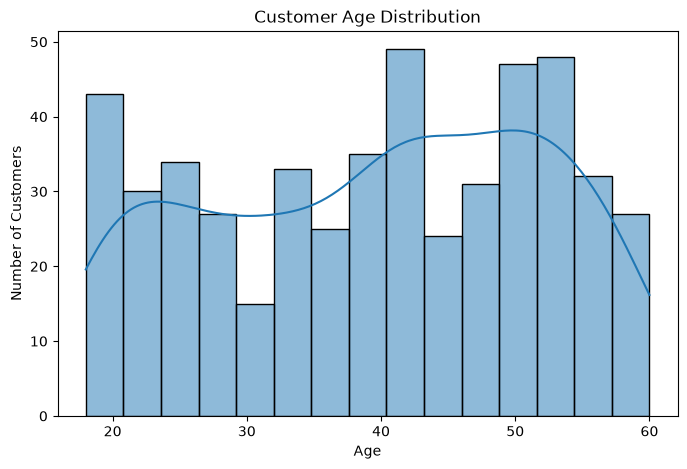

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    customers_df["age"],
    bins=15,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

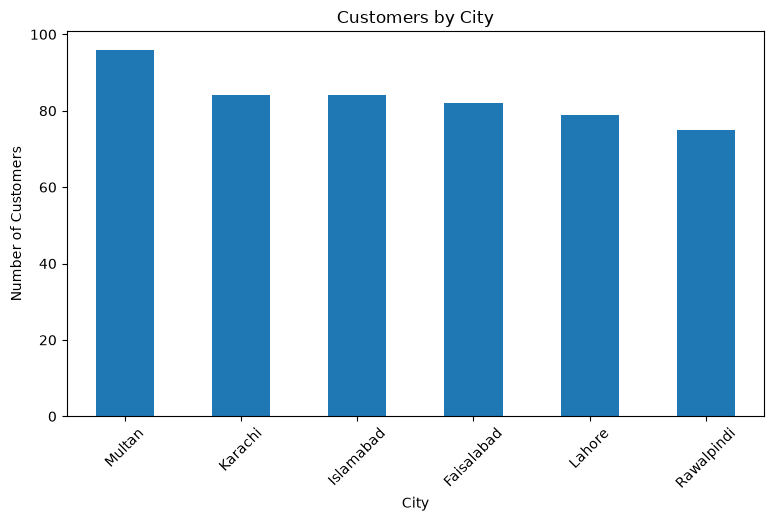

In [34]:
plt.figure(figsize=(9, 5))

customers_df["city"].value_counts().plot(
    kind="bar"
)

plt.title("Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [35]:
# Merge orders with product information

sales_df = orders_df.merge(
    products_df,
    on="product_id",
    how="left"
)

# Calculate revenue before discount
sales_df["gross_revenue"] = (
    sales_df["quantity"] * sales_df["price"]
)

# Calculate discount amount
sales_df["discount_amount"] = (
    sales_df["gross_revenue"]
    * sales_df["discount_percent"]
    / 100
)

# Calculate final revenue
sales_df["revenue"] = (
    sales_df["gross_revenue"]
    - sales_df["discount_amount"]
)

sales_df.head()

,order_id,customer_id,product_id,order_date,quantity,discount_percent,product_name,category,price,gross_revenue,discount_amount,revenue
0,O01913,C0188,P0095,2025-01-01,4,0,Mechanical Keyboard,Accessories,23884,95536,0.00,95536.00
1,O02968,C0385,P0048,2025-01-01,1,25,Laptop Stand,Accessories,35405,35405,8851.25,26553.75
2,O00428,C0343,P0005,2025-01-01,5,25,Mechanical Keyboard,Electronics,12056,60280,15070.00,45210.00
3,O00753,C0459,P0096,2025-01-01,1,10,Mechanical Keyboard,Accessories,645,645,64.50,580.50
4,O00701,C0014,P0017,2025-01-02,1,25,Smart Watch,Electronics,25096,25096,6274.00,18822.00


In [36]:
total_revenue = sales_df["revenue"].sum()

print(f"Total Revenue: Rs. {total_revenue:,.2f}")

Total Revenue: Rs. 219,366,570.60


In [37]:
total_items = sales_df["quantity"].sum()

print("Total Items Sold:", total_items)

Total Items Sold: 9184


In [38]:
average_order_value = (
    sales_df["revenue"].sum()
    / sales_df["order_id"].nunique()
)

print(f"Average Order Value: Rs. {average_order_value:,.2f}")

Average Order Value: Rs. 73,122.19


In [39]:
category_revenue = (
    sales_df
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Electronics       69039851.50
Accessories       58530479.45
Fashion           46876925.85
Home & Kitchen    44919313.80
Name: revenue, dtype: float64

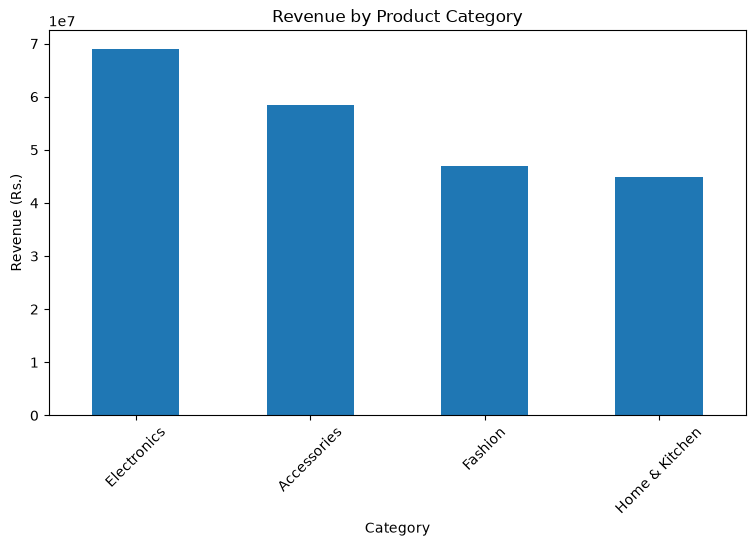

In [40]:
plt.figure(figsize=(9, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (Rs.)")
plt.xticks(rotation=45)

plt.show()

In [41]:
top_products = (
    sales_df
    .groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Wireless Mouse         31096106.85
Smart Watch            29055543.65
Bluetooth Speaker      25864852.40
Mechanical Keyboard    24882112.90
Headphones             21420684.05
Backpack               20291017.55
Power Bank             18815654.50
Laptop Stand           18323612.85
Phone Case             16375906.55
USB-C Cable            13241079.30
Name: revenue, dtype: float64

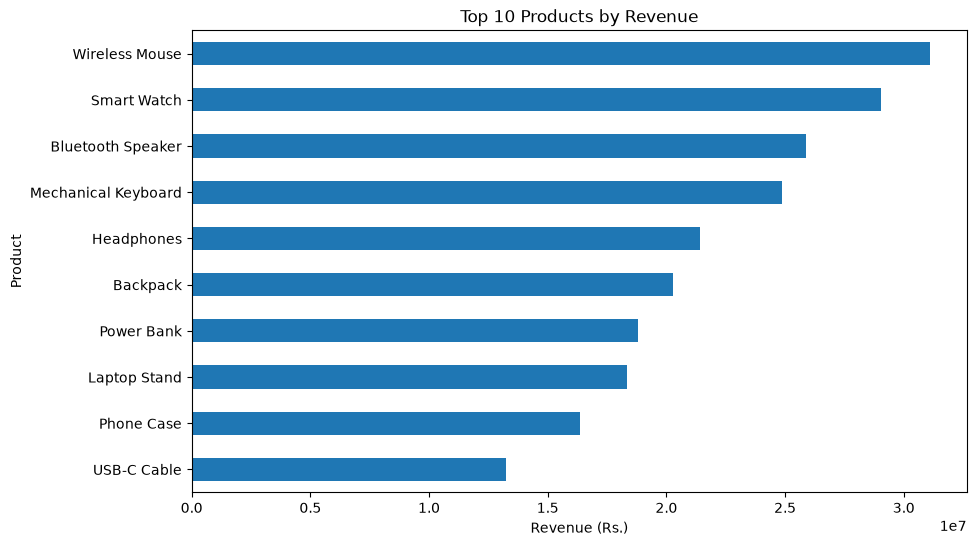

In [42]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (Rs.)")
plt.ylabel("Product")

plt.show()

In [43]:
sales_df["month"] = (
    sales_df["order_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    sales_df
    .groupby("month")["revenue"]
    .sum()
)

monthly_revenue

month
2025-01    12097228.60
2025-02    10911247.55
2025-03    13967747.35
2025-04    11808673.80
2025-05    11264867.70
2025-06    11631926.05
2025-07    13131355.45
2025-08    14324254.85
2025-09    11580382.15
2025-10    12113234.65
2025-11    13139725.15
2025-12    10397583.30
2026-01    14650409.60
2026-02     9022634.80
2026-03    12454932.50
2026-04    12874471.20
2026-05    12142944.20
2026-06    11852951.70
Name: revenue, dtype: float64

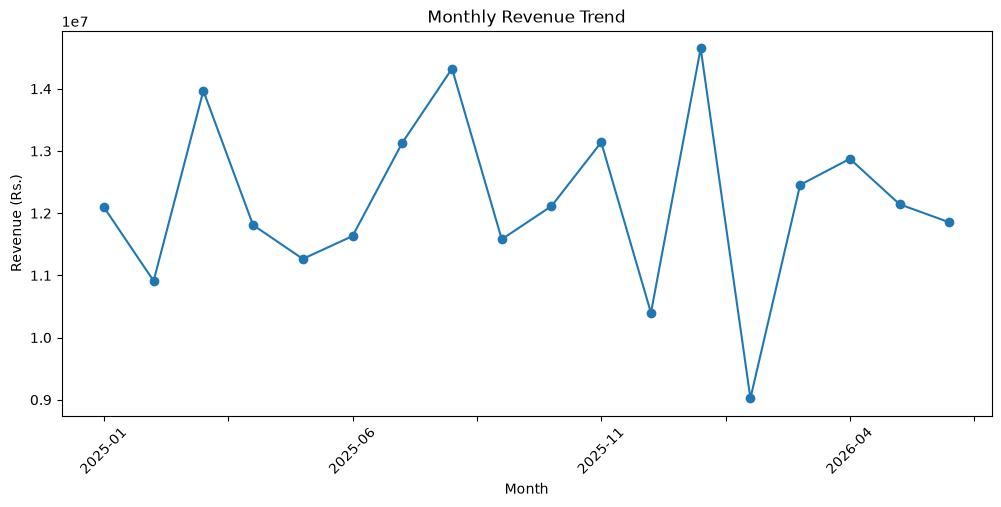

In [44]:
plt.figure(figsize=(12, 5))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs.)")

plt.xticks(rotation=45)

plt.show()

In [45]:
monthly_orders = (
    sales_df
    .groupby("month")["order_id"]
    .nunique()
)

monthly_orders

month
2025-01    171
2025-02    150
2025-03    191
2025-04    162
2025-05    165
2025-06    162
2025-07    170
2025-08    194
2025-09    155
2025-10    164
2025-11    174
2025-12    152
2026-01    186
2026-02    140
2026-03    174
2026-04    165
2026-05    151
2026-06    174
Name: order_id, dtype: int64

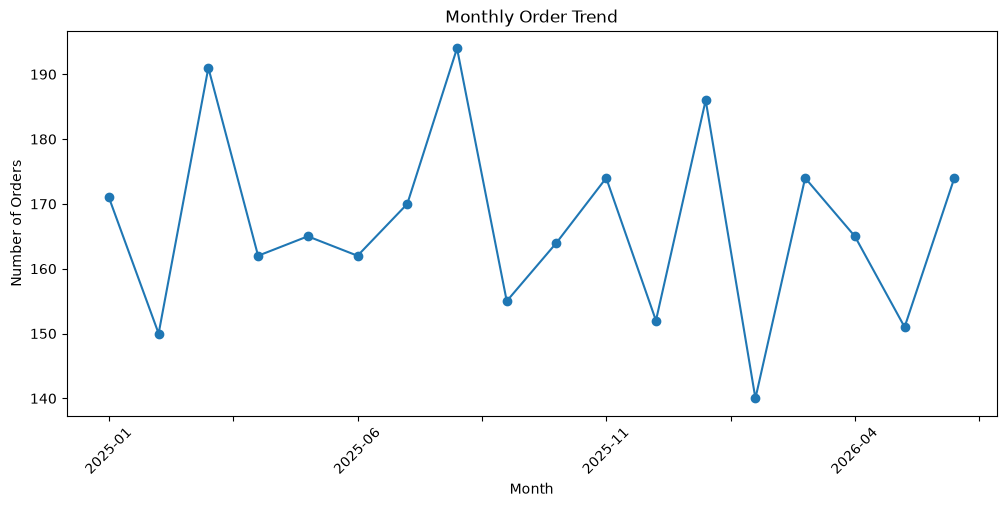

In [46]:
plt.figure(figsize=(12, 5))

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [47]:
sales_customer_df = sales_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

city_revenue = (
    sales_customer_df
    .groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue

city
Multan        43606218.70
Faisalabad    37402955.05
Karachi       35448772.70
Islamabad     35101633.10
Lahore        34468333.90
Rawalpindi    33338657.15
Name: revenue, dtype: float64

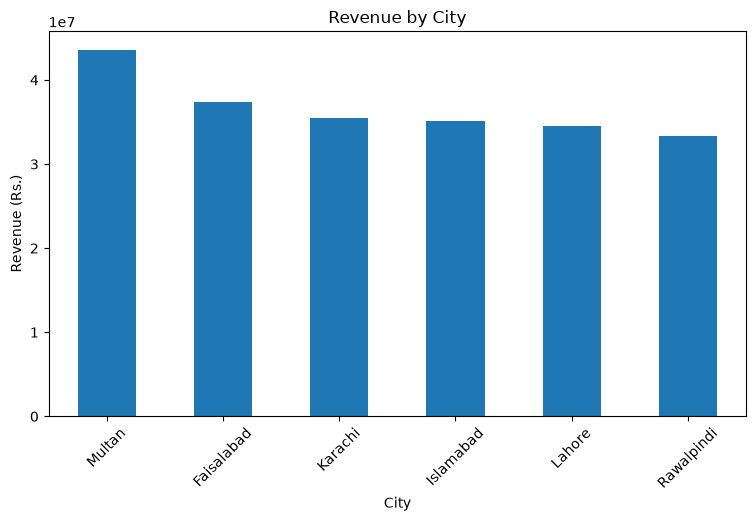

In [48]:
plt.figure(figsize=(9, 5))

city_revenue.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (Rs.)")
plt.xticks(rotation=45)

plt.show()

In [49]:
customer_summary = (
    sales_customer_df
    .groupby(["customer_id", "age", "gender", "city"])
    .agg(
        total_orders=("order_id", "nunique"),
        total_items=("quantity", "sum"),
        total_spent=("revenue", "sum"),
        avg_order_value=("revenue", "mean")
    )
    .reset_index()
)

customer_summary.head(10)

,customer_id,age,gender,city,total_orders,total_items,total_spent,avg_order_value
0,C0001,56,Female,Multan,4,11,350946.00,87736.500000
1,C0002,46,Male,Lahore,5,17,395059.35,79011.870000
2,C0003,32,Male,Multan,8,20,540642.80,67580.350000
3,C0004,60,Female,Rawalpindi,4,17,182037.70,45509.425000
4,C0005,25,Female,Karachi,8,24,553053.00,69131.625000
5,C0006,38,Male,Karachi,2,5,209456.00,104728.000000
6,C0007,56,Female,Faisalabad,7,20,641557.60,91651.085714
7,C0008,36,Female,Rawalpindi,10,32,639324.35,63932.435000
8,C0009,40,Male,Karachi,1,4,127481.60,127481.600000
9,C0010,28,Female,Rawalpindi,6,13,474066.70,79011.116667


In [50]:
total_customers = customers_df["customer_id"].nunique()

active_customers = customer_summary["customer_id"].nunique()

print("Total Customers:", total_customers)
print("Active Customers:", active_customers)

Total Customers: 500
Active Customers: 500


In [51]:
total_customers = customers_df["customer_id"].nunique()

active_customers = customer_summary["customer_id"].nunique()

print("Total Customers:", total_customers)
print("Active Customers:", active_customers)

Total Customers: 500
Active Customers: 500


In [52]:
repeat_customers = customer_summary[
    customer_summary["total_orders"] >= 2
]

print("Repeat Customers:", len(repeat_customers))

Repeat Customers: 492


In [53]:
repeat_customer_rate = (
    len(repeat_customers)
    / active_customers
) * 100

print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

Repeat Customer Rate: 98.40%


In [54]:
top_customers = (
    customer_summary
    .sort_values("total_spent", ascending=False)
    .head(10)
)

top_customers[
    [
        "customer_id",
        "city",
        "total_orders",
        "total_items",
        "total_spent"
    ]
]

,customer_id,city,total_orders,total_items,total_spent
404,C0405,Multan,13,44,1107003.25
353,C0354,Rawalpindi,11,43,1083121.05
148,C0149,Faisalabad,13,39,1031281.80
108,C0109,Karachi,12,34,1023765.10
153,C0154,Islamabad,14,39,1005171.05
434,C0435,Rawalpindi,10,34,1001985.75
140,C0141,Faisalabad,9,38,994456.05
424,C0425,Multan,12,43,992270.70
360,C0361,Islamabad,8,30,933118.10
386,C0387,Faisalabad,9,33,910419.10


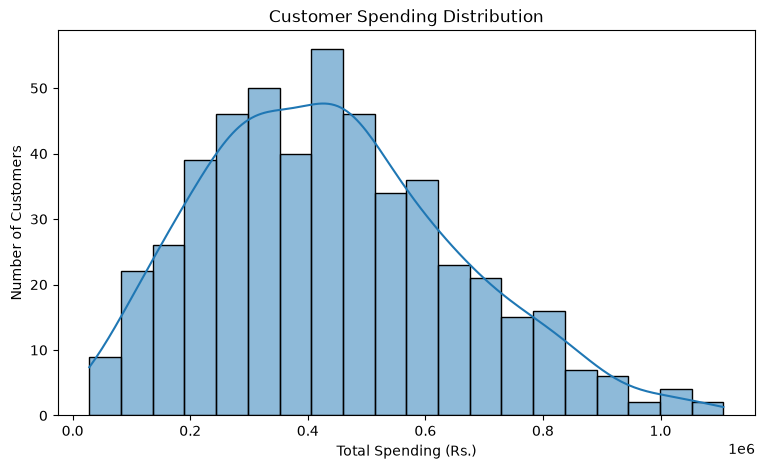

In [55]:
plt.figure(figsize=(9, 5))

sns.histplot(
    customer_summary["total_spent"],
    bins=20,
    kde=True
)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending (Rs.)")
plt.ylabel("Number of Customers")

plt.show()

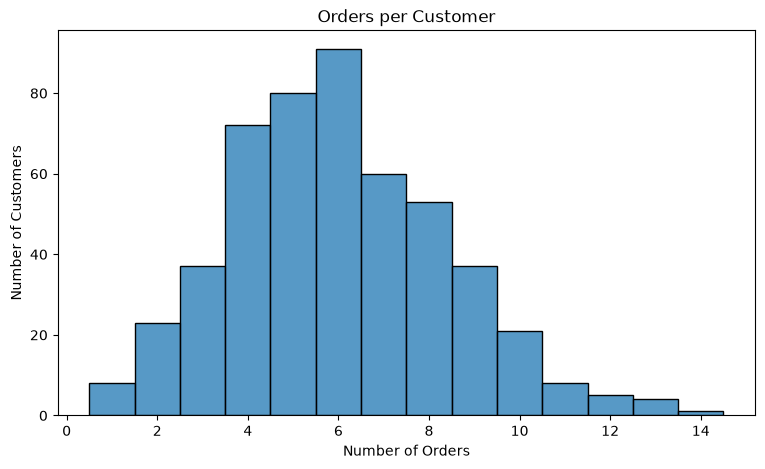

In [56]:
plt.figure(figsize=(9, 5))

sns.histplot(
    customer_summary["total_orders"],
    bins=15,
    discrete=True
)

plt.title("Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

In [57]:
customer_summary["customer_segment"] = pd.qcut(
    customer_summary["total_spent"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop"
)

customer_summary[
    [
        "customer_id",
        "total_spent",
        "customer_segment"
    ]
].head(10)

,customer_id,total_spent,customer_segment
0,C0001,350946.00,Medium Value
1,C0002,395059.35,Medium Value
2,C0003,540642.80,High Value
3,C0004,182037.70,Low Value
4,C0005,553053.00,High Value
5,C0006,209456.00,Low Value
6,C0007,641557.60,High Value
7,C0008,639324.35,High Value
8,C0009,127481.60,Low Value
9,C0010,474066.70,Medium Value


In [58]:
segment_counts = (
    customer_summary["customer_segment"]
    .value_counts()
)

segment_counts

customer_segment
Low Value       167
High Value      167
Medium Value    166
Name: count, dtype: int64

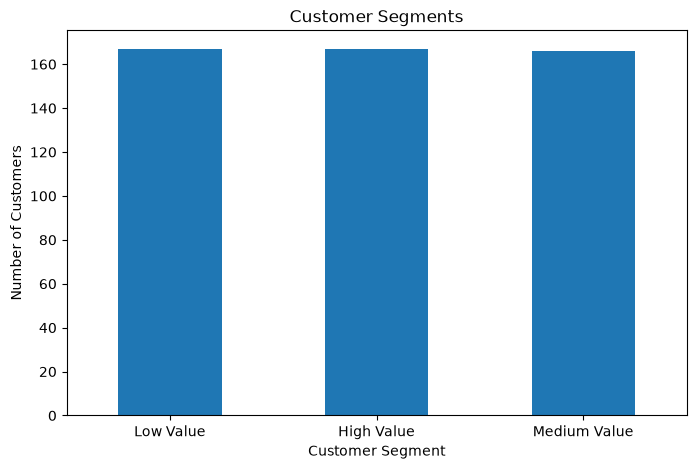

In [59]:
plt.figure(figsize=(8, 5))

segment_counts.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [60]:
segment_revenue = (
    customer_summary
    .groupby("customer_segment", observed=True)["total_spent"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

customer_segment
High Value      1.138188e+08
Medium Value    6.965257e+07
Low Value       3.589522e+07
Name: total_spent, dtype: float64

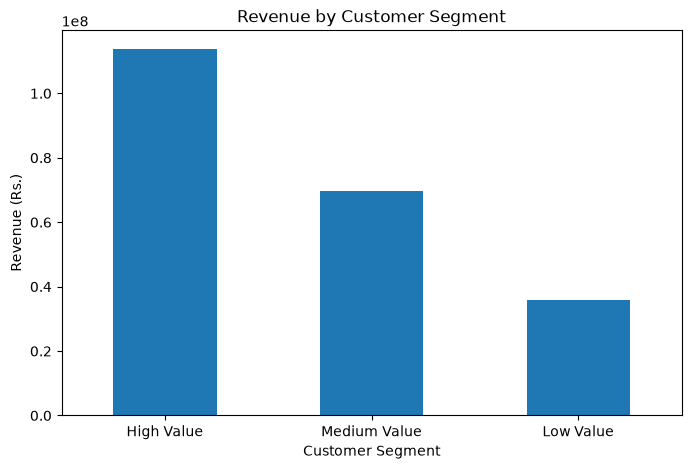

In [61]:
plt.figure(figsize=(8, 5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (Rs.)")

plt.xticks(rotation=0)

plt.show()

In [62]:
# Reference date for churn analysis
reference_date = orders_df["order_date"].max()

print("Reference Date:", reference_date)

Reference Date: 2026-06-30 00:00:00


In [63]:
customer_ml = (
    sales_customer_df
    .groupby("customer_id")
    .agg(
        age=("age", "first"),
        total_orders=("order_id", "nunique"),
        total_items=("quantity", "sum"),
        total_spent=("revenue", "sum"),
        avg_order_value=("revenue", "mean"),
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

customer_ml.head()

,customer_id,age,total_orders,total_items,total_spent,avg_order_value,last_order_date
0,C0001,56,4,11,350946.00,87736.500,2026-06-24
1,C0002,46,5,17,395059.35,79011.870,2026-06-11
2,C0003,32,8,20,540642.80,67580.350,2026-05-26
3,C0004,60,4,17,182037.70,45509.425,2026-05-21
4,C0005,25,8,24,553053.00,69131.625,2026-06-06


In [64]:
customer_ml["recency_days"] = (
    reference_date - customer_ml["last_order_date"]
).dt.days

customer_ml.head()

,customer_id,age,total_orders,total_items,total_spent,avg_order_value,last_order_date,recency_days
0,C0001,56,4,11,350946.00,87736.500,2026-06-24,6
1,C0002,46,5,17,395059.35,79011.870,2026-06-11,19
2,C0003,32,8,20,540642.80,67580.350,2026-05-26,35
3,C0004,60,4,17,182037.70,45509.425,2026-05-21,40
4,C0005,25,8,24,553053.00,69131.625,2026-06-06,24


In [65]:
customer_ml["churn"] = (
    customer_ml["recency_days"] > 90
).astype(int)

customer_ml.head()

,customer_id,age,total_orders,total_items,total_spent,avg_order_value,last_order_date,recency_days,churn
0,C0001,56,4,11,350946.00,87736.500,2026-06-24,6,0
1,C0002,46,5,17,395059.35,79011.870,2026-06-11,19,0
2,C0003,32,8,20,540642.80,67580.350,2026-05-26,35,0
3,C0004,60,4,17,182037.70,45509.425,2026-05-21,40,0
4,C0005,25,8,24,553053.00,69131.625,2026-06-06,24,0


In [66]:
churn_counts = customer_ml["churn"].value_counts()

print("Active Customers:", churn_counts.get(0, 0))
print("Churned Customers:", churn_counts.get(1, 0))

Active Customers: 311
Churned Customers: 189


In [67]:
churn_rate = customer_ml["churn"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 37.80%


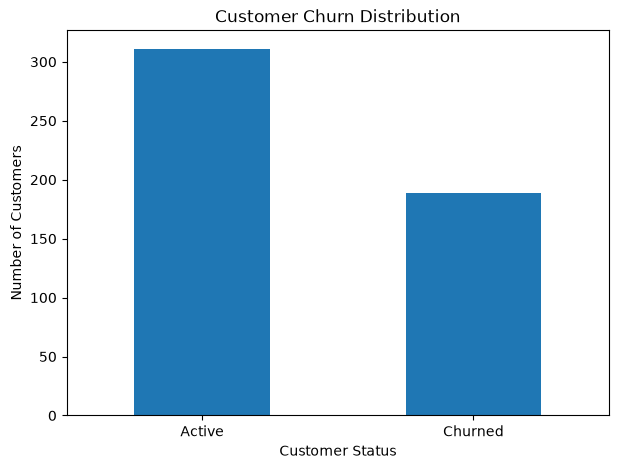

In [68]:
plt.figure(figsize=(7, 5))

customer_ml["churn"].value_counts().rename(
    {0: "Active", 1: "Churned"}
).plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [69]:
customer_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      500 non-null    str           
 1   age              500 non-null    int64         
 2   total_orders     500 non-null    int64         
 3   total_items      500 non-null    int64         
 4   total_spent      500 non-null    float64       
 5   avg_order_value  500 non-null    float64       
 6   last_order_date  500 non-null    datetime64[us]
 7   recency_days     500 non-null    int64         
 8   churn            500 non-null    int64         
dtypes: datetime64[us](1), float64(2), int64(5), str(1)
memory usage: 35.3 KB


In [70]:
customer_ml[
    [
        "age",
        "total_orders",
        "total_items",
        "total_spent",
        "avg_order_value",
        "recency_days",
        "churn"
    ]
].describe()

,age,total_orders,total_items,total_spent,avg_order_value,recency_days,churn
count,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.000000
mean,39.506000,6.000000,18.368000,4.387331e+05,73772.035266,90.946000,0.378000
std,12.368505,2.389858,8.032286,2.133332e+05,25036.183967,91.775206,0.485373
min,18.000000,1.000000,1.000000,2.836540e+04,14182.700000,0.000000,0.000000
25%,29.000000,4.000000,13.000000,2.822286e+05,57327.187500,24.000000,0.000000
50%,41.000000,6.000000,18.000000,4.276766e+05,71253.743750,65.000000,0.000000
75%,50.000000,8.000000,24.000000,5.780871e+05,87143.511607,129.250000,1.000000
max,60.000000,14.000000,44.000000,1.107003e+06,175924.800000,501.000000,1.000000


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Machine Learning libraries loaded successfully!")

Machine Learning libraries loaded successfully!


In [72]:
features = [
    "age",
    "total_orders",
    "total_items",
    "total_spent",
    "avg_order_value",
    "recency_days"
]

X = customer_ml[features]
y = customer_ml["churn"]

print("Features:", features)
print("Target: churn")

Features: ['age', 'total_orders', 'total_items', 'total_spent', 'avg_order_value', 'recency_days']
Target: churn


In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 400
Testing records: 100


In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [75]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Churn prediction model trained successfully!")

Churn prediction model trained successfully!


In [76]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0]


In [77]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 99.00%


In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        62
           1       1.00      0.97      0.99        38

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



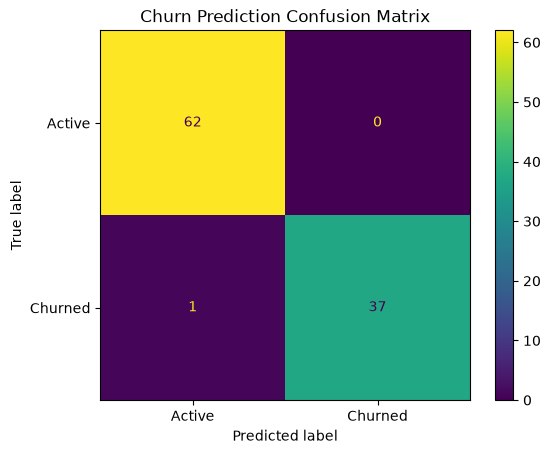

In [79]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Active", "Churned"]
)

disp.plot()

plt.title("Churn Prediction Confusion Matrix")
plt.show()

In [80]:
churn_probability = model.predict_proba(X_test_scaled)[:, 1]

prediction_results = X_test.copy()

prediction_results["actual_churn"] = y_test.values
prediction_results["predicted_churn"] = y_pred
prediction_results["churn_probability"] = churn_probability

prediction_results.head(10)

,age,total_orders,total_items,total_spent,avg_order_value,recency_days,actual_churn,predicted_churn,churn_probability
131,49,6,15,392364.70,65394.116667,79,0,0,0.303292
490,42,3,10,204330.90,68110.300000,113,1,1,0.799223
249,26,5,16,242077.00,48415.400000,69,0,0,0.160475
209,33,7,26,661540.55,94505.792857,66,0,0,0.121819
345,56,2,4,55520.20,27760.100000,359,1,1,1.000000
132,56,5,16,240160.80,48032.160000,49,0,0,0.045498
310,46,5,15,434590.75,86918.150000,167,1,1,0.993946
269,46,5,12,148726.55,29745.310000,72,0,0,0.203120
488,46,8,27,686347.55,85793.443750,1,0,0,0.001717
418,39,9,24,618506.35,68722.927778,38,0,0,0.025622


In [81]:
def risk_level(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


prediction_results["risk_level"] = (
    prediction_results["churn_probability"]
    .apply(risk_level)
)

prediction_results.head(10)

,age,total_orders,total_items,total_spent,avg_order_value,recency_days,actual_churn,predicted_churn,churn_probability,risk_level
131,49,6,15,392364.70,65394.116667,79,0,0,0.303292,Low Risk
490,42,3,10,204330.90,68110.300000,113,1,1,0.799223,High Risk
249,26,5,16,242077.00,48415.400000,69,0,0,0.160475,Low Risk
209,33,7,26,661540.55,94505.792857,66,0,0,0.121819,Low Risk
345,56,2,4,55520.20,27760.100000,359,1,1,1.000000,High Risk
132,56,5,16,240160.80,48032.160000,49,0,0,0.045498,Low Risk
310,46,5,15,434590.75,86918.150000,167,1,1,0.993946,High Risk
269,46,5,12,148726.55,29745.310000,72,0,0,0.203120,Low Risk
488,46,8,27,686347.55,85793.443750,1,0,0,0.001717,Low Risk
418,39,9,24,618506.35,68722.927778,38,0,0,0.025622,Low Risk


In [82]:
# Predict churn probability for ALL customers

X_all_scaled = scaler.transform(X)

customer_ml["churn_probability"] = (
    model.predict_proba(X_all_scaled)[:, 1]
)

customer_ml["predicted_churn"] = (
    model.predict(X_all_scaled)
)

print("Predictions generated for all customers!")

Predictions generated for all customers!


In [83]:
customer_ml["risk_level"] = (
    customer_ml["churn_probability"]
    .apply(risk_level)
)

customer_ml[
    [
        "customer_id",
        "total_orders",
        "total_spent",
        "recency_days",
        "churn_probability",
        "predicted_churn",
        "risk_level"
    ]
].head(10)

,customer_id,total_orders,total_spent,recency_days,churn_probability,predicted_churn,risk_level
0,C0001,4,350946.00,6,0.003036,0,Low Risk
1,C0002,5,395059.35,19,0.006382,0,Low Risk
2,C0003,8,540642.80,35,0.022100,0,Low Risk
3,C0004,4,182037.70,40,0.021650,0,Low Risk
4,C0005,8,553053.00,24,0.009275,0,Low Risk
5,C0006,2,209456.00,190,0.998950,1,High Risk
6,C0007,7,641557.60,119,0.859935,1,High Risk
7,C0008,10,639324.35,112,0.772151,1,High Risk
8,C0009,1,127481.60,239,0.999965,1,High Risk
9,C0010,6,474066.70,125,0.916963,1,High Risk


In [85]:
# High Risk Customers

high_risk_customers = customer_ml[
    customer_ml["risk_level"] == "High Risk"
].copy()

# Display important customer information
high_risk_customers[
    [
        "customer_id",
        "age",
        "total_orders",
        "total_spent",
        "recency_days",
        "churn_probability",
        "risk_level"
    ]
].sort_values(
    "churn_probability",
    ascending=False
).head(20)

,customer_id,age,total_orders,total_spent,recency_days,churn_probability,risk_level
295,C0296,44,1,39182.40,501,1.0,High Risk
179,C0180,29,2,97534.75,471,1.0,High Risk
457,C0458,52,1,153112.00,465,1.0,High Risk
372,C0373,59,1,44290.00,454,1.0,High Risk
305,C0306,21,3,95347.70,440,1.0,High Risk
497,C0498,52,1,112826.75,432,1.0,High Risk
122,C0123,31,2,60532.60,432,1.0,High Risk
296,C0297,44,2,119870.40,431,1.0,High Risk
332,C0333,49,5,558939.55,397,1.0,High Risk
346,C0347,46,5,318885.65,385,1.0,High Risk


In [86]:
risk_distribution = (
    customer_ml["risk_level"]
    .value_counts()
)

risk_distribution

risk_level
Low Risk       305
High Risk      160
Medium Risk     35
Name: count, dtype: int64

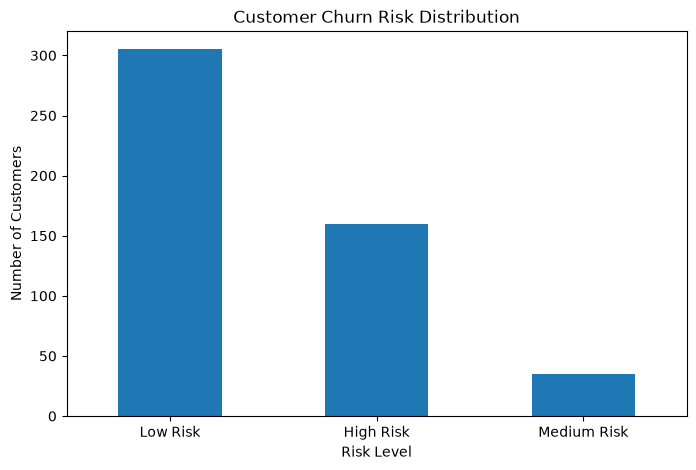

In [87]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [88]:
customer_ml.to_csv(
    "../data/customer_churn_predictions.csv",
    index=False
)

print("Customer churn predictions saved successfully!")

Customer churn predictions saved successfully!


In [89]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

joblib.dump(
    scaler,
    "../models/churn_scaler.pkl"
)

print("ML model and scaler saved successfully!")

ML model and scaler saved successfully!


In [90]:
print("Model:", model)
print("Scaler:", scaler)
print("Prediction file created:", "../data/customer_churn_predictions.csv")

Model: LogisticRegression(max_iter=1000, random_state=42)
Scaler: StandardScaler()
Prediction file created: ../data/customer_churn_predictions.csv


In [91]:
# ============================================
# STEP 13 - Prepare Power BI Dashboard Data
# ============================================

import os

# Make sure dashboard folder exists
os.makedirs("../dashboard", exist_ok=True)

# --------------------------------------------
# 1. Sales Dashboard Data
# --------------------------------------------

dashboard_sales = sales_customer_df.copy()

dashboard_sales.to_csv(
    "../dashboard/dashboard_sales.csv",
    index=False
)

print("Sales dashboard file created successfully!")


# --------------------------------------------
# 2. Customer Churn Dashboard Data
# --------------------------------------------

dashboard_customers = customer_ml.copy()

dashboard_customers.to_csv(
    "../dashboard/dashboard_customers.csv",
    index=False
)

print("Customer dashboard file created successfully!")


# --------------------------------------------
# 3. Show final files
# --------------------------------------------

print("\nDashboard files:")
print("- dashboard_sales.csv")
print("- dashboard_customers.csv")

Sales dashboard file created successfully!
Customer dashboard file created successfully!

Dashboard files:
- dashboard_sales.csv
- dashboard_customers.csv
